<a href="https://colab.research.google.com/github/KT313-cloud/study/blob/main/competition2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
!pip install japanize-matplotlib lightgbm xgboost optuna --quiet

In [30]:
# モジュールのインポート
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import japanize_matplotlib  # 日本語表示用
from sklearn.base import clone
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning
from lightgbm import XGBClassifier
from xgboost import XGBClassifier
import optuna
from sklearn.metrics import roc_auc_score
import sklearn.model_selection as skm
from sklearn.pipeline import Pipeline
warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [31]:
PATH = '/content/drive/MyDrive/Colab Notebooks/GCI2026_Summer/03.コンペ2（6-16公開）/data/'

In [32]:
train = pd.read_csv(PATH + 'train.csv')
test = pd.read_csv(PATH + 'test.csv')
print('Train:', train.shape, ' Test:', test.shape)

Train: (1568, 22)  Test: (672, 21)


In [33]:
median_income = train['annual_income'].median()
for df in [train, test]:
    df['annual_income'] = df['annual_income'].fillna(median_income)

In [34]:
train = pd.get_dummies(
    train,
    columns=['education_level', 'marital_status'],
    drop_first=True
)
test = pd.get_dummies(
    test,
    columns=['education_level', 'marital_status'],
    drop_first=True
)

In [35]:
train.sort_values('registration_date',ascending=False)[["registration_date","days_since_last_purchase","deals_purchases","web_purchases","catalog_purchases","store_purchases"]]

,registration_date,days_since_last_purchase,deals_purchases,web_purchases,catalog_purchases,store_purchases
1022,2014-12-06,29,1,0,0,3
837,2014-12-05,16,2,2,0,4
751,2014-12-05,49,2,4,2,11
611,2014-12-05,70,1,5,6,7
300,2014-12-05,29,1,4,2,10
...,...,...,...,...,...,...
463,2012-01-10,31,2,3,2,9
540,2012-01-09,99,1,8,5,4
266,2012-01-08,61,2,9,5,6
99,2012-01-08,19,5,4,1,2


In [36]:
train_no=train.copy()
test_no=test.copy()
for df in [train_no, test_no]:
    df.drop(columns=['customer_id', 'registration_date'], inplace=True)
print('Train欠損:', train.isnull().sum().sum(), ' 列:', list(train.columns))

Train欠損: 0  列: ['customer_id', 'birth_year', 'annual_income', 'num_children', 'num_teenagers', 'registration_date', 'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'has_complaint', 'target', 'education_level_Bachelor', 'education_level_Doctorate', 'education_level_High School', 'education_level_Master', 'marital_status_Married', 'marital_status_Other', 'marital_status_Partner', 'marital_status_Single', 'marital_status_Widowed']


In [37]:
X = train_no.drop(columns=['target'])
y = train_no['target']

Cs = [0.01,0.03,0.05,0.1,0.3, 0.5,1, 10]
ratios = [0,0.1,0.2,0.3,0.4, 0.5,0.6,0.7,0.8, 0.9,1]
clf=LogisticRegression(penalty="elasticnet",solver="saga",max_iter=5000,n_jobs=-1)
pipe= Pipeline([('scaler',StandardScaler()),
             ('elas',clf)])
tuned_parameters = {'elas__C': Cs,'elas__l1_ratio':ratios}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_log = skm.GridSearchCV(
    pipe, # 識別器
    tuned_parameters, # 最適化したいパラメータセット
    cv=cv, # 交差検定の回数
    scoring= 'roc_auc',
    n_jobs=-1)

grid_log.fit(X,y)
print(grid_log.best_params_)
print(grid_log.best_score_)
print(grid_log.best_estimator_.named_steps['elas'].coef_[0])

{'elas__C': 0.1, 'elas__l1_ratio': 0.3}
0.8214209295963876
[ 4.10176696e-02  0.00000000e+00  7.35604007e-02 -4.65147165e-01
 -6.57782496e-01  4.76282804e-01 -1.85540449e-04  3.82837691e-01
 -1.92983425e-02  2.75869867e-02  1.63920914e-01  1.24658672e-01
  2.56838942e-01  1.88005321e-01 -4.23643600e-01  3.44315360e-01
  0.00000000e+00 -4.10796258e-03  2.24868168e-01 -7.70875133e-02
  1.37177587e-01 -3.39250643e-01 -3.03982763e-02 -3.50979031e-01
  2.09297780e-02  8.36688396e-02]


In [38]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def cv_auc(model, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = []
    for tr_idx, va_idx in skf.split(X, y):
        m = clone(model)
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        p = m.predict_proba(X.iloc[va_idx])[:, 1]
        scores.append(roc_auc_score(y.iloc[va_idx], p))
    return np.mean(scores), scores

def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 600),
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 7, 63),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 80),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    )
    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    mean_auc, _ = cv_auc(model, X, y)
    return mean_auc

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)  # 試行回数。増やすほど時間がかかる
print(f'Optuna ベスト CV AUC = {study.best_value:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Optuna ベスト CV AUC = 0.8496


In [39]:
spend_cols = [
    'spend_wines',
    'spend_fruits',
    'spend_meat',
    'spend_fish',
    'spend_sweets',
    'spend_gold'
]
for df in [train_no, test_no]:
  df['total_spend'] = df[spend_cols].sum(axis=1)
  for col in spend_cols:
    df[col+"_ratio"] = df[col] / (df['total_spend'] + 1)

In [40]:
X = train_no.drop(columns=['target'])
y = train_no['target']

Cs = [0.01,0.03,0.05,0.1,0.3, 0.5,1, 10]
ratios = [0,0.1,0.2,0.3,0.4, 0.5,0.6,0.7,0.8, 0.9,1]
clf=LogisticRegression(penalty="elasticnet",solver="saga",max_iter=5000,n_jobs=-1)
pipe= Pipeline([('scaler',StandardScaler()),
             ('elas',clf)])
tuned_parameters = {'elas__C': Cs,'elas__l1_ratio':ratios}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_log = skm.GridSearchCV(
    pipe, # 識別器
    tuned_parameters, # 最適化したいパラメータセット
    cv=cv, # 交差検定の回数
    scoring= 'roc_auc',
    n_jobs=-1)

grid_log.fit(X,y)
print(grid_log.best_params_)
print(grid_log.best_score_)
print(grid_log.best_estimator_.named_steps['elas'].coef_[0])

{'elas__C': 0.3, 'elas__l1_ratio': 1}
0.8343095340863357
[ 0.          0.02815174  0.         -0.43607205 -0.72450271  0.88884885
  0.03594621  0.          0.10953848  0.01912546  0.          0.18385938
  0.27046481  0.18108652 -0.36879685  0.36437541 -0.01976233  0.
  0.28653953 -0.09513689  0.13395046 -0.40327339 -0.02390297 -0.39337684
  0.          0.08459525  0.05845797  0.         -0.03618582  0.54630484
 -0.16791587  0.09495174  0.58955163]


In [41]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)  # 試行回数。増やすほど時間がかかる
print(f'Optuna ベスト CV AUC = {study.best_value:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Optuna ベスト CV AUC = 0.8503


In [42]:
for df in [train_no, test_no]:
  for col in spend_cols:
    df[col+"_annual_ratio"] = df[col] / (df['annual_income'] + 1)

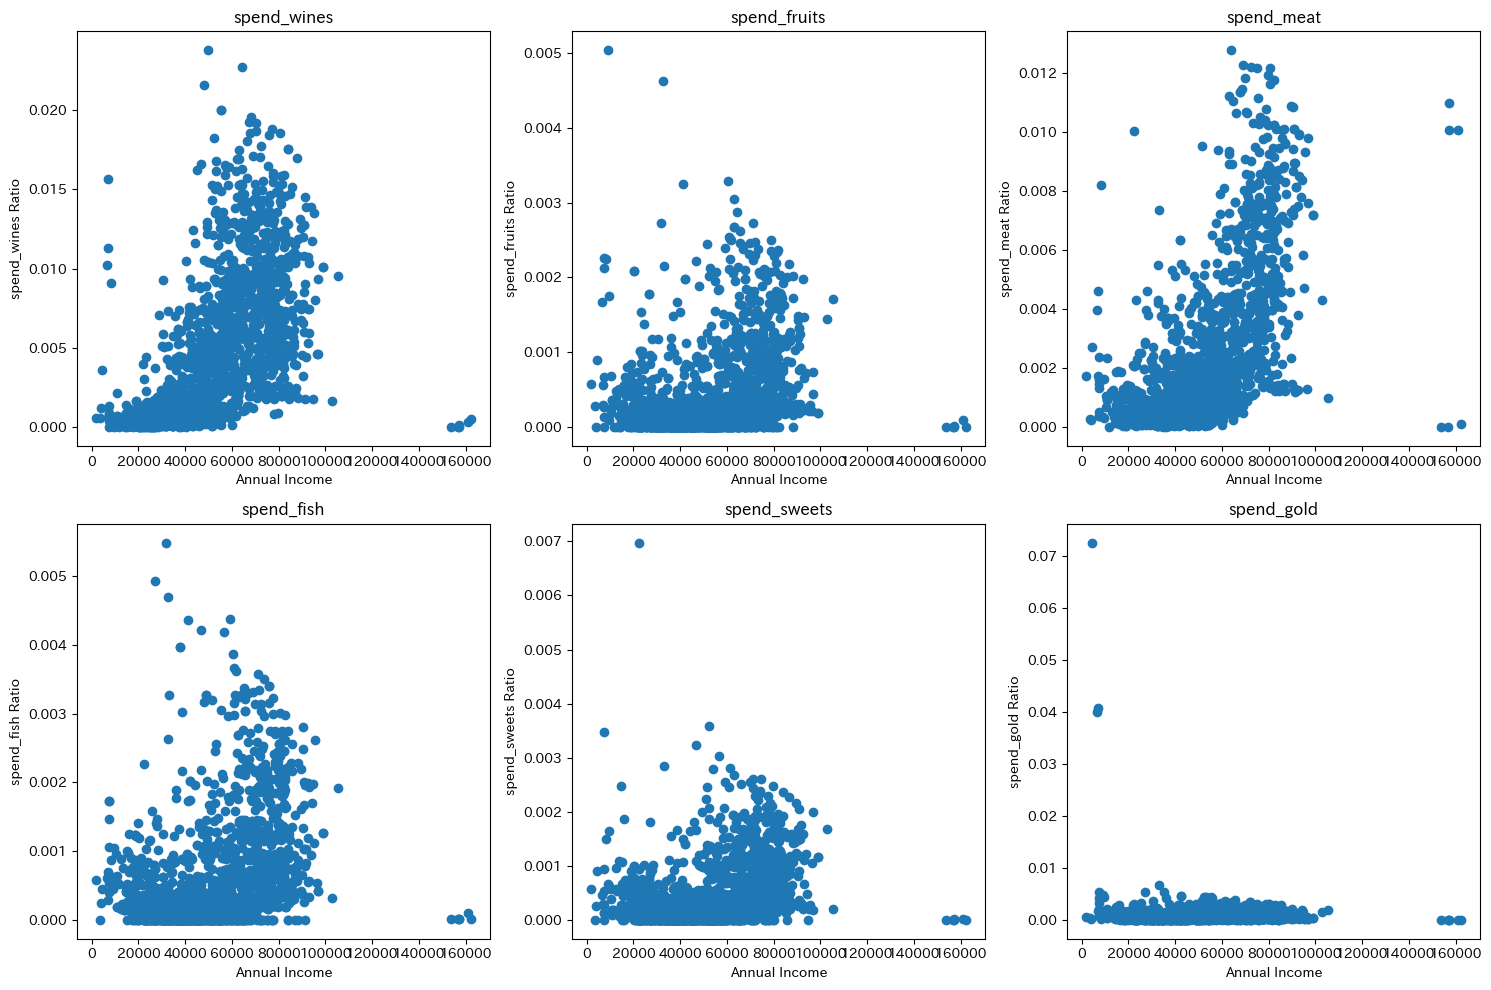

In [43]:
for df in [train_no, test_no]:
  df['total_spend'] = df[spend_cols].sum(axis=1)
  for col in spend_cols:
    df[col+"_annual_ratio"] = df[col] / (df['annual_income'] + 1)

train_cut=train_no[train_no['annual_income']<200000]
fig,axes=plt.subplots(2,3, figsize=(15, 10))
axes_flat = axes.flatten() # Flatten the 2x3 array of axes for easier iteration
for i,col in enumerate(spend_cols):
  # The number of spend_cols matches the number of subplots, so no need for 'if i < len(axes_flat)'
  axes_flat[i].scatter(train_cut['annual_income'],train_cut[col+'_annual_ratio'])
  axes_flat[i].set_title(col)
  axes_flat[i].set_xlabel('Annual Income') # Add x-label
  axes_flat[i].set_ylabel(f'{col} Ratio') # Add y-label
plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

In [44]:
cols_to_drop = [col for col in train.columns if col.endswith('_ratio') ]
train.drop(columns=cols_to_drop, inplace=True)

In [45]:
for df in [train_no, test_no]:
  df['total_spend']=df[spend_cols].sum(axis=1)
  df['engels']=(df['total_spend']-df['spend_gold'])/df['annual_income']
  for col in spend_cols:
    df[col+"_ratio"] = df[col] / (df['total_spend'] + 1)

In [46]:
X = train_no.drop(columns=['target'])
y = train_no['target']

Cs = [0.01,0.1,0.3, 0.5,1, 10]
ratios = [0,0.1,0.2,0.3,0.4, 0.5,0.6,0.7,0.8, 0.9,1]
clf=LogisticRegression(penalty="elasticnet",solver="saga",max_iter=5000,n_jobs=-1)
pipe= Pipeline([('scaler',StandardScaler()),
             ('elas',clf)])
tuned_parameters = {'elas__C': Cs,'elas__l1_ratio':ratios}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_log = skm.GridSearchCV(
    pipe, # 識別器
    tuned_parameters, # 最適化したいパラメータセット
    cv=cv, # 交差検定の回数
    scoring= 'roc_auc',
    n_jobs=-1)

grid_log.fit(X,y)
print(grid_log.best_params_)
print(grid_log.best_score_)
print(grid_log.best_estimator_.named_steps['elas'].coef_[0])

{'elas__C': 0.1, 'elas__l1_ratio': 0.5}
0.8338083408690109
[ 1.55669716e-04  0.00000000e+00  0.00000000e+00 -3.86476257e-01
 -6.74341829e-01  5.45265669e-01  0.00000000e+00  0.00000000e+00
  1.89164594e-02  9.29793533e-03  1.34383682e-02  1.40355572e-01
  3.43987443e-01  1.55083082e-01 -3.46101656e-01  3.05286086e-01
 -9.19320301e-04  0.00000000e+00  2.59142428e-01 -8.49348603e-02
  1.14778914e-01 -3.33883296e-01 -1.68304355e-02 -3.34745688e-01
  2.10816879e-02  7.99867262e-02  3.40545268e-01  0.00000000e+00
 -2.11868382e-02  3.50694295e-01 -1.32630773e-01  2.61152039e-02
  6.06805064e-01  0.00000000e+00  0.00000000e+00  1.03498141e-01
  0.00000000e+00  0.00000000e+00 -2.26627162e-01  0.00000000e+00]


In [47]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)  # 試行回数。増やすほど時間がかかる
print(f'Optuna ベスト CV AUC = {study.best_value:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Optuna ベスト CV AUC = 0.8517


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


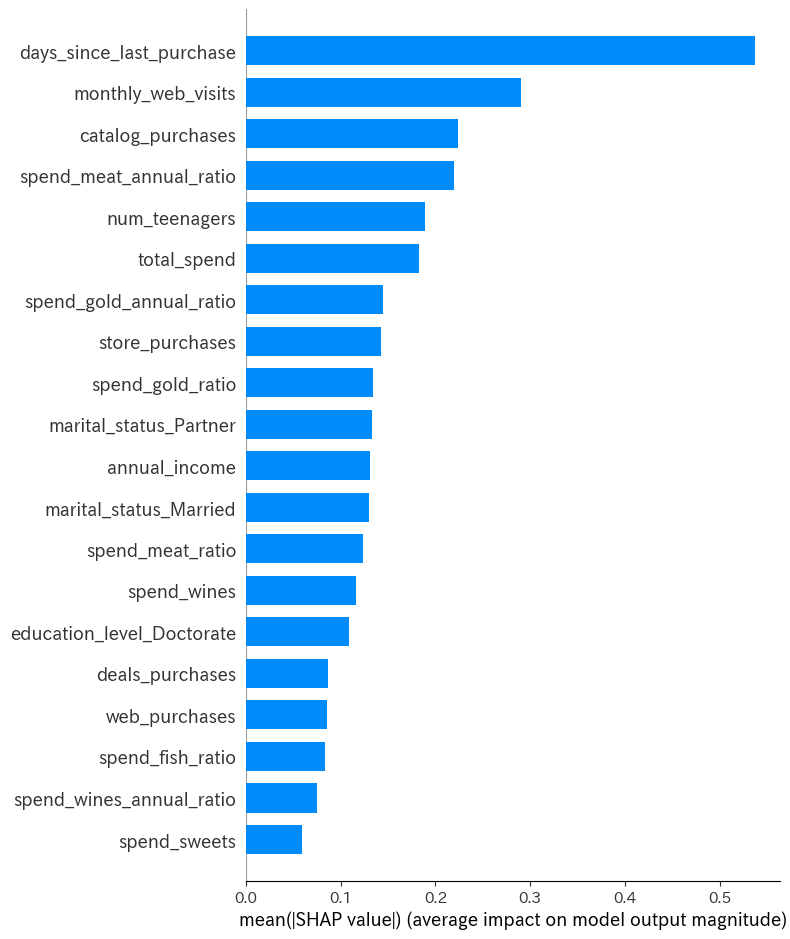

In [49]:
import shap
from shap import TreeExplainer

# Optunaで得られた最適なパラメータを使ってLGBMClassifierを再構築・学習
best_lgbm_params = study.best_params
best_lgbm = LGBMClassifier(**best_XGB_params, random_state=42, verbose=-1)
best_lgbm.fit(X, y)

explainer=shap.TreeExplainer(best_lgbm)
shap_values=explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar")

In [50]:
for df in [train, test]:
  date = pd.to_datetime(df["registration_date"])
  df["registration_index"] = (
    (date.dt.year - 2012) * 12
    + date.dt.month
)

In [51]:
for df in [train, test]:
    df.drop(columns=['customer_id', 'registration_date'], inplace=True)
print('Train欠損:', train.isnull().sum().sum(), ' 列:', list(train.columns))

Train欠損: 0  列: ['birth_year', 'annual_income', 'num_children', 'num_teenagers', 'days_since_last_purchase', 'spend_wines', 'spend_fruits', 'spend_meat', 'spend_fish', 'spend_sweets', 'spend_gold', 'deals_purchases', 'web_purchases', 'catalog_purchases', 'store_purchases', 'monthly_web_visits', 'has_complaint', 'target', 'education_level_Bachelor', 'education_level_Doctorate', 'education_level_High School', 'education_level_Master', 'marital_status_Married', 'marital_status_Other', 'marital_status_Partner', 'marital_status_Single', 'marital_status_Widowed', 'registration_index']


In [52]:
X = train.drop(columns=['target'])
y = train['target']

Cs = [0.03,0.1,0.3, 0.5,1, 10]
ratios = [0,0.1,0.2,0.3,0.4, 0.5,0.6,0.7,0.8, 0.9,1]
clf=LogisticRegression(penalty="elasticnet",solver="saga",max_iter=5000,n_jobs=-1)
pipe= Pipeline([('scaler',StandardScaler()),
             ('elas',clf)])
tuned_parameters = {'elas__C': Cs,'elas__l1_ratio':ratios}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_log = skm.GridSearchCV(
    pipe, # 識別器
    tuned_parameters, # 最適化したいパラメータセット
    cv=cv, # 交差検定の回数
    scoring= 'roc_auc',
    n_jobs=-1)

grid_log.fit(X,y)
print(grid_log.best_params_)
print(grid_log.best_score_)
print(grid_log.best_estimator_.named_steps['elas'].coef_[0])

{'elas__C': 0.03, 'elas__l1_ratio': 0.1}
0.8340362386180399
[ 0.03781964  0.          0.05424324 -0.36788902 -0.56149397  0.37542044
  0.          0.31468299 -0.0183077   0.00839196  0.12029041  0.07576473
  0.19669206  0.17285086 -0.32931614  0.18378453  0.         -0.03322943
  0.18602103 -0.09186841  0.10372823 -0.22386592 -0.00531406 -0.24087557
  0.08849975  0.09636686 -0.35118301]


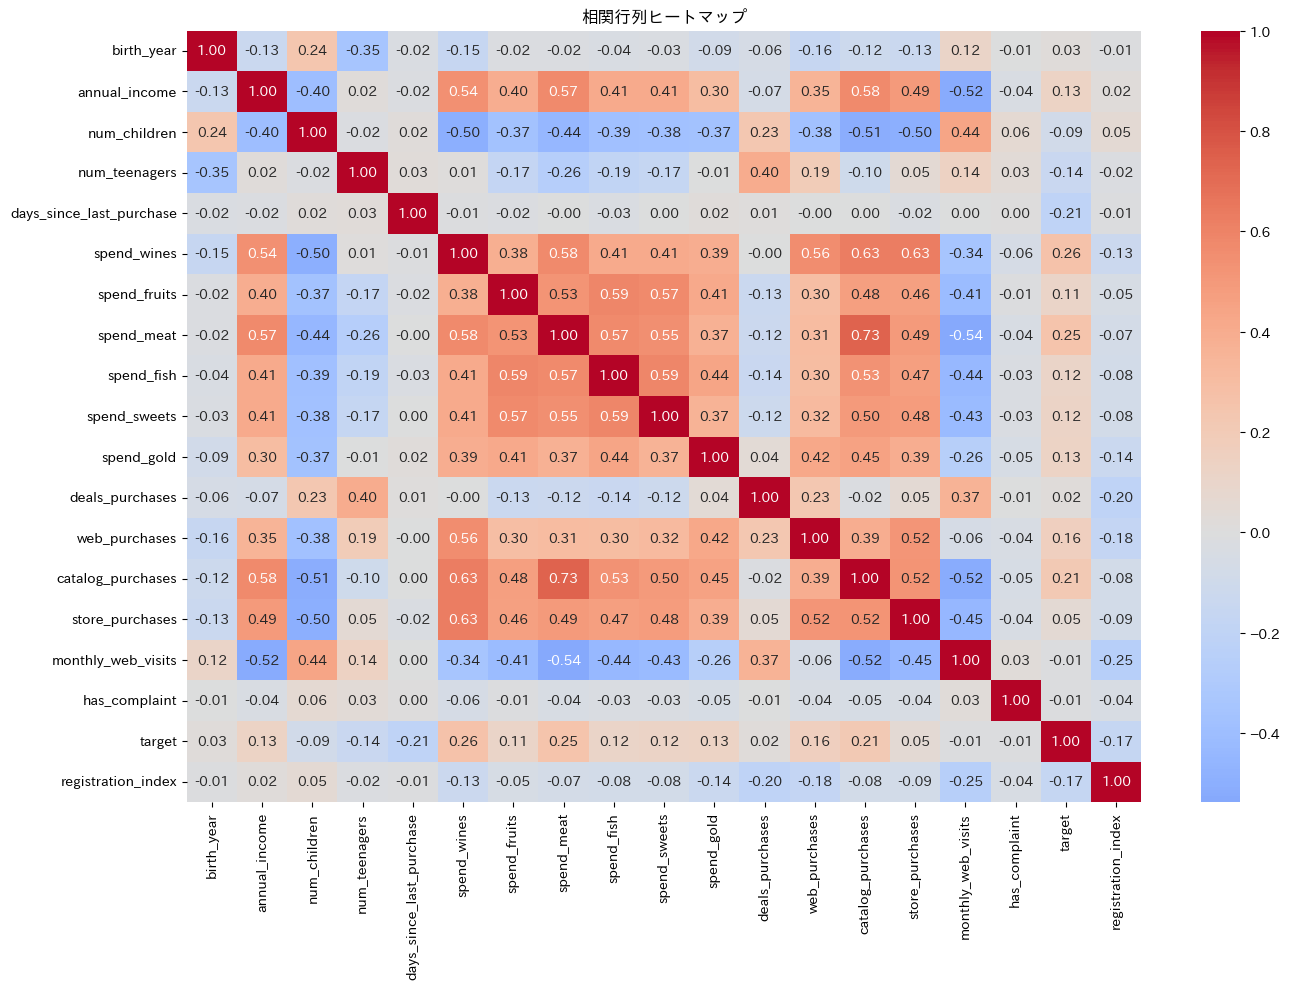

In [53]:
numeric_for_corr = train.select_dtypes(include=['number'])

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_for_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('相関行列ヒートマップ')
plt.tight_layout()
plt.show()

In [54]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)  # 試行回数。増やすほど時間がかかる
print(f'Optuna ベスト CV AUC = {study.best_value:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Optuna ベスト CV AUC = 0.8635


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


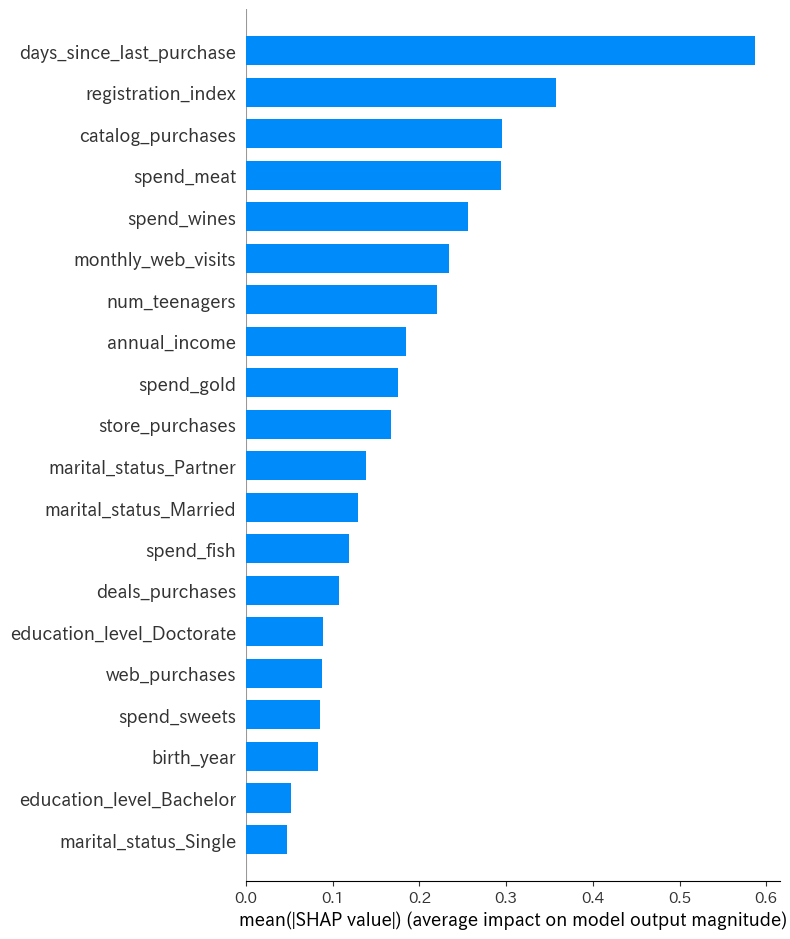

In [55]:
# Optunaで得られた最適なパラメータを使ってLGBMClassifierを再構築・学習
best_lgbm_params = study.best_params
best_lgbm = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)
best_lgbm.fit(X, y)

explainer=shap.TreeExplainer(best_lgbm)
shap_values=explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar")

In [56]:
for df in [train, test]:
  df['total_spend']=df[spend_cols].sum(axis=1)
  df['engels']=(df['total_spend']-df['spend_gold'])/df['annual_income']
  for col in spend_cols:
    df[col+"_ratio"] = df[col] / (df['total_spend'] + 1)

In [57]:
X = train.drop(columns=['target'])
y = train['target']

Cs = [0.01,0.03,0.05,0.1,0.3, 0.5,1, 10]
ratios = [0,0.1,0.2,0.3,0.4, 0.5,0.6,0.7,0.8, 0.9,1]
clf=LogisticRegression(penalty="elasticnet",solver="saga",max_iter=5000,n_jobs=-1)
pipe= Pipeline([('scaler',StandardScaler()),
             ('elas',clf)])
tuned_parameters = {'elas__C': Cs,'elas__l1_ratio':ratios}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_log = skm.GridSearchCV(
    pipe, # 識別器
    tuned_parameters, # 最適化したいパラメータセット
    cv=cv, # 交差検定の回数
    scoring= 'roc_auc',
    n_jobs=-1)

grid_log.fit(X,y)
print(grid_log.best_params_)
print(grid_log.best_score_)
print(grid_log.best_estimator_.named_steps['elas'].coef_[0])

{'elas__C': 0.1, 'elas__l1_ratio': 0.5}
0.842860005776376
[ 0.          0.          0.00460345 -0.40599938 -0.67788224  0.54862016
  0.          0.          0.          0.          0.          0.1265785
  0.21985126  0.15967588 -0.36526199  0.19593838 -0.0032496   0.
  0.25161369 -0.10462091  0.11472749 -0.3351588  -0.00194574 -0.33394683
  0.02257045  0.08558362 -0.39728796  0.31498064  0.          0.
 -0.00248126  0.38512911 -0.13379548  0.03409378  0.41098553]


In [58]:
coef = pd.Series(
    grid_log.best_estimator_.named_steps["elas"].coef_[0],
    index=X.columns
)

coef.sort_values(key=abs, ascending=False)

,0
days_since_last_purchase,-0.677882
spend_wines,0.548620
spend_gold_ratio,0.410986
num_teenagers,-0.405999
registration_index,-0.397288
spend_meat_ratio,0.385129
store_purchases,-0.365262
marital_status_Married,-0.335159
marital_status_Partner,-0.333947
total_spend,0.314981


In [59]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)  # 試行回数。増やすほど時間がかかる
print(f'Optuna ベスト CV AUC = {study.best_value:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Optuna ベスト CV AUC = 0.8656


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


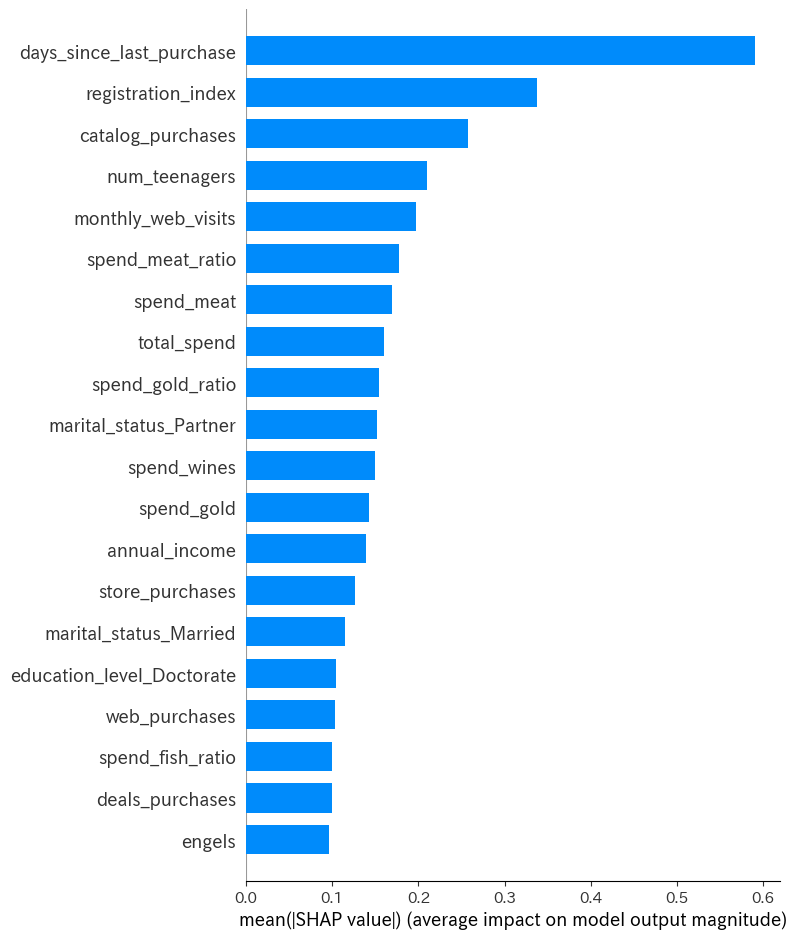

In [60]:
# Optunaで得られた最適なパラメータを使ってLGBMClassifierを再構築・学習
best_lgbm_params = study.best_params
best_lgbm = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)
best_lgbm.fit(X, y)

explainer=shap.TreeExplainer(best_lgbm)
shap_values=explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar")

In [61]:
X = train.drop(columns=['target'])
y = train['target']

Cs = [0.01,0.03,0.05,0.1,0.3, 0.5,1]
ratios = [0,0.1,0.3, 0.5,0.7, 0.9]
clf=LogisticRegression(penalty="elasticnet",solver="saga",max_iter=5000,n_jobs=-1)
pipe= Pipeline([('scaler',StandardScaler()),
             ('elas',clf)])
tuned_parameters = {'elas__C': Cs,'elas__l1_ratio':ratios}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_log = skm.GridSearchCV(
    pipe, # 識別器
    tuned_parameters, # 最適化したいパラメータセット
    cv=cv, # 交差検定の回数
    scoring= 'roc_auc',
    n_jobs=-1)

grid_log.fit(X,y)
print(grid_log.best_params_)
print(grid_log.best_score_)
coef = pd.Series(
    grid_log.best_estimator_.named_steps["elas"].coef_[0],
    index=X.columns
)

print(coef.sort_values(key=abs, ascending=False))

{'elas__C': 0.1, 'elas__l1_ratio': 0.5}
0.842860005776376
days_since_last_purchase      -0.677883
spend_wines                    0.548636
spend_gold_ratio               0.410988
num_teenagers                 -0.406000
registration_index            -0.397290
spend_meat_ratio               0.385135
store_purchases               -0.365262
marital_status_Married        -0.335159
marital_status_Partner        -0.333947
total_spend                    0.314961
education_level_Doctorate      0.251613
web_purchases                  0.219852
monthly_web_visits             0.195936
catalog_purchases              0.159677
spend_fish_ratio              -0.133794
deals_purchases                0.126579
education_level_Master         0.114727
education_level_High School   -0.104621
marital_status_Widowed         0.085584
spend_sweets_ratio             0.034096
marital_status_Single          0.022570
num_children                   0.004603
has_complaint                 -0.003250
spend_fruits_ratio    

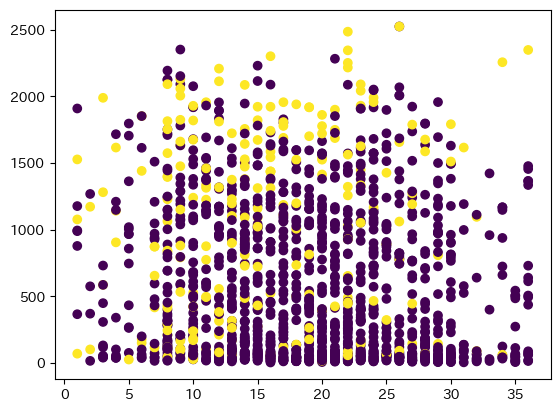

In [62]:
plt.scatter(train['registration_index'],train['total_spend'],c=train['target'])

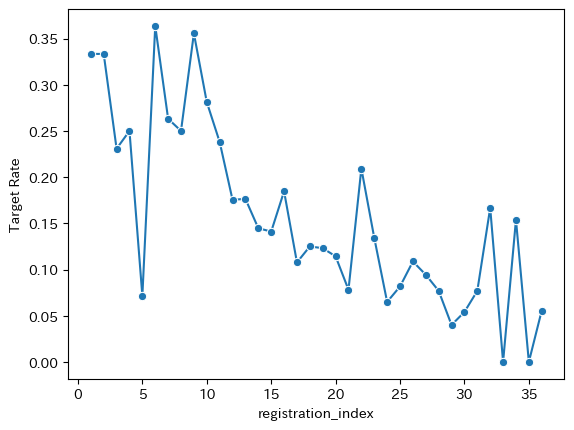

In [63]:
rate = (
    train.groupby("registration_index")["target"]
         .mean()
         .reset_index()
)

sns.lineplot(data=rate, x="registration_index", y="target", marker="o")
plt.ylabel("Target Rate")
plt.show()

In [64]:
for df in [train,test]:
  df['customer_split']=(df['registration_index']<22)

In [65]:
X = train.drop(columns=['target'])
y = train['target']

Cs = [0.01,0.03,0.05,0.1,0.3, 0.5,1]
ratios = [0,0.1,0.3, 0.5,0.7, 0.9]
clf=LogisticRegression(penalty="elasticnet",solver="saga",max_iter=5000,n_jobs=-1)
pipe= Pipeline([('scaler',StandardScaler()),
             ('elas',clf)])
tuned_parameters = {'elas__C': Cs,'elas__l1_ratio':ratios}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_log = skm.GridSearchCV(
    pipe, # 識別器
    tuned_parameters, # 最適化したいパラメータセット
    cv=cv, # 交差検定の回数
    scoring= 'roc_auc',
    n_jobs=-1)

grid_log.fit(X,y)
print(grid_log.best_params_)
print(grid_log.best_score_)
coef = pd.Series(
    grid_log.best_estimator_.named_steps["elas"].coef_[0],
    index=X.columns
)

print(coef.sort_values(key=abs, ascending=False))

{'elas__C': 0.1, 'elas__l1_ratio': 0.5}
0.842445630128914
days_since_last_purchase      -0.677882
spend_wines                    0.548612
spend_gold_ratio               0.410984
num_teenagers                 -0.405999
registration_index            -0.397289
spend_meat_ratio               0.385126
store_purchases               -0.365262
marital_status_Married        -0.335158
marital_status_Partner        -0.333948
total_spend                    0.314988
education_level_Doctorate      0.251614
web_purchases                  0.219851
monthly_web_visits             0.195940
catalog_purchases              0.159676
spend_fish_ratio              -0.133797
deals_purchases                0.126578
education_level_Master         0.114727
education_level_High School   -0.104620
marital_status_Widowed         0.085583
spend_sweets_ratio             0.034094
marital_status_Single          0.022569
num_children                   0.004604
has_complaint                 -0.003249
spend_fruits_ratio    

In [79]:
for df in [train,test]:
  df.drop(columns=['customer_split'], inplace=True)
  df['deals_rate']=df['deals_purchases']/(df['web_purchases']+df['store_purchases']+df['catalog_purchases']+1)

In [80]:
X = train.drop(columns=['target'])
y = train['target']

Cs = [0.01,0.03,0.05,0.1,0.3, 0.5,1]
ratios = [0,0.1,0.3, 0.5,0.7, 0.9]
clf=LogisticRegression(penalty="elasticnet",solver="saga",max_iter=5000,n_jobs=-1)
pipe= Pipeline([('scaler',StandardScaler()),
             ('elas',clf)])
tuned_parameters = {'elas__C': Cs,'elas__l1_ratio':ratios}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_log = skm.GridSearchCV(
    pipe, # 識別器
    tuned_parameters, # 最適化したいパラメータセット
    cv=cv, # 交差検定の回数
    scoring= 'roc_auc',
    n_jobs=-1)

grid_log.fit(X,y)
print(grid_log.best_params_)
print(grid_log.best_score_)
coef = pd.Series(
    grid_log.best_estimator_.named_steps["elas"].coef_[0],
    index=X.columns
)

print(coef.sort_values(key=abs, ascending=False))

{'elas__C': 0.1, 'elas__l1_ratio': 0.5}
0.8431946338838188
days_since_last_purchase      -0.676646
spend_wines                    0.545565
num_teenagers                 -0.413961
spend_gold_ratio               0.409287
registration_index            -0.387811
spend_meat_ratio               0.385049
store_purchases               -0.370102
marital_status_Married        -0.338253
marital_status_Partner        -0.337552
total_spend                    0.326561
education_level_Doctorate      0.251602
monthly_web_visits             0.215692
web_purchases                  0.208560
catalog_purchases              0.158917
deals_purchases                0.152555
spend_fish_ratio              -0.132403
education_level_Master         0.113975
education_level_High School   -0.106288
marital_status_Widowed         0.084675
deals_rate                    -0.054163
spend_sweets_ratio             0.037248
marital_status_Single          0.020579
marital_status_Other          -0.003185
has_complaint        

In [81]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)  # 試行回数。増やすほど時間がかかる
print(f'Optuna ベスト CV AUC = {study.best_value:.4f}')

  0%|          | 0/30 [00:00<?, ?it/s]

Optuna ベスト CV AUC = 0.8648


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


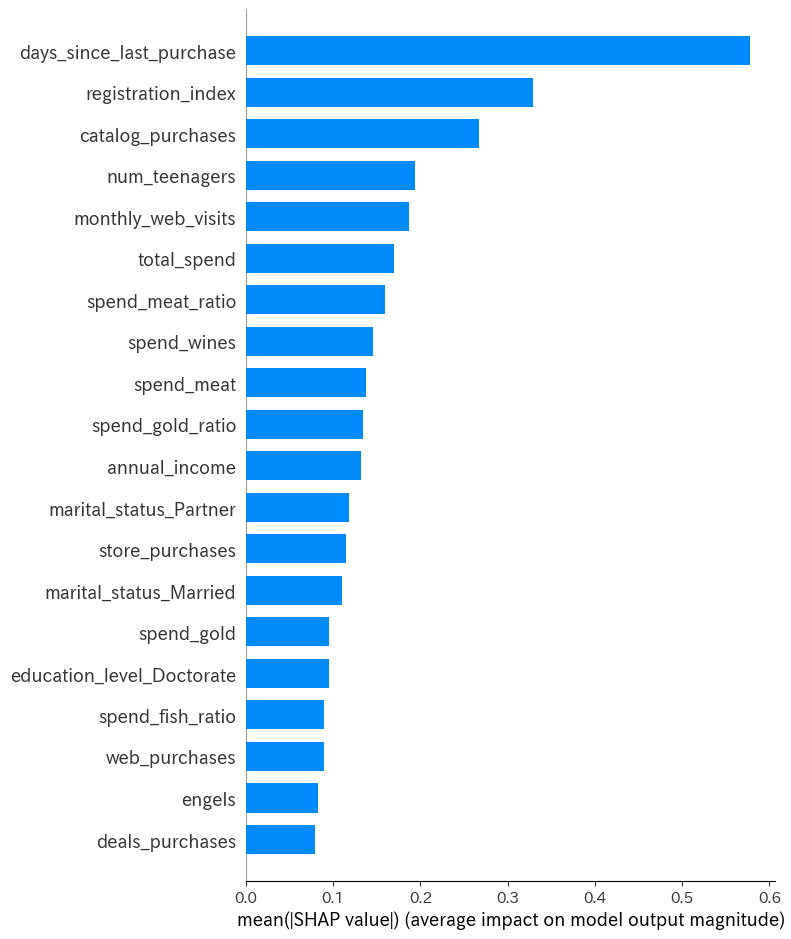

In [83]:
# Optunaで得られた最適なパラメータを使ってLGBMClassifierを再構築・学習
best_lgbm_params = study.best_params
best_lgbm = LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1)
best_lgbm.fit(X, y)

explainer=shap.TreeExplainer(best_lgbm)
shap_values=explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar")

In [89]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42),
    'LogisticRegression': make_pipeline(StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    'LightGBM': LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1),
    'MLP': make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
    'XGBoost': XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
        eval_metric='logloss', random_state=42),
}

cv_scores = {}
for name, model in models.items():
    mean_auc, _ = cv_auc(model, X, y)
    cv_scores[name] = mean_auc
    print(f'{name:20s} CV AUC = {mean_auc:.4f}')

RandomForest         CV AUC = 0.8353
LogisticRegression   CV AUC = 0.8418
LightGBM             CV AUC = 0.8648
MLP                  CV AUC = 0.8383
XGBoost              CV AUC = 0.8478


In [90]:
def objective_xgb(trial):
    params = dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        min_child_weight=trial.suggest_float("min_child_weight", 1.0, 10.0),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    )

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )

    mean_auc, _ = cv_auc(model, X, y)
    return mean_auc

In [91]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=100)

print(study_xgb.best_value)
print(study_xgb.best_params)

0.8691567160685654
{'n_estimators': 692, 'learning_rate': 0.022596383661973623, 'max_depth': 6, 'min_child_weight': 3.71892669651989, 'subsample': 0.833210005232371, 'colsample_bytree': 0.781854140674345, 'gamma': 2.615994394156619, 'reg_lambda': 0.0499216283229999, 'reg_alpha': 0.002133920318111342}


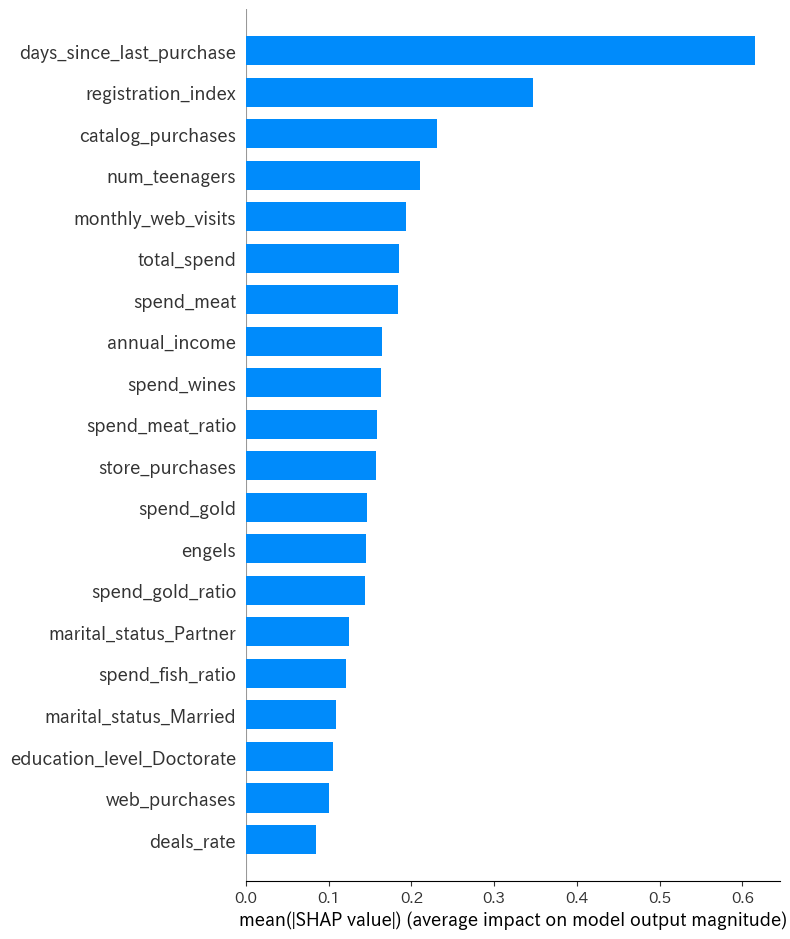

In [93]:
best_xgb_params = study_xgb.best_params
best_xgb = XGBClassifier(
    **best_xgb_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
best_xgb.fit(X, y)
explainer=shap.TreeExplainer(best_xgb)
shap_values=explainer.shap_values(X)
shap.summary_plot(shap_values, X, plot_type="bar")

In [96]:
models = {
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42),
    'LogisticRegression': make_pipeline(StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)),
    'LightGBM': LGBMClassifier(**best_lgbm_params, random_state=42, verbose=-1),
    'MLP': make_pipeline(StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)),
    'XGBoost': best_xgb
}

cv_scores = {}
for name, model in models.items():
    mean_auc, _ = cv_auc(model, X, y)
    cv_scores[name] = mean_auc
    print(f'{name:20s} CV AUC = {mean_auc:.4f}')

RandomForest         CV AUC = 0.8353
LogisticRegression   CV AUC = 0.8418
LightGBM             CV AUC = 0.8648
MLP                  CV AUC = 0.8383
XGBoost              CV AUC = 0.8692
